In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

In [2]:
columns = ['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety', 'class']
df = pd.read_csv('car_data', names = columns)
print("Forma na podatocite ", df.shape)
df.head()

Forma na podatocite  (1728, 7)


,buying,maint,doors,persons,lug_boot,safety,class
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc


In [4]:
df.info()

for col in df.columns:
    print(f"{col}: {df[col].unique()}")

<class 'pandas.DataFrame'>
RangeIndex: 1728 entries, 0 to 1727
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   buying    1728 non-null   str  
 1   maint     1728 non-null   str  
 2   doors     1728 non-null   str  
 3   persons   1728 non-null   str  
 4   lug_boot  1728 non-null   str  
 5   safety    1728 non-null   str  
 6   class     1728 non-null   str  
dtypes: str(7)
memory usage: 94.6 KB
buying: <StringArray>
['vhigh', 'high', 'med', 'low']
Length: 4, dtype: str
maint: <StringArray>
['vhigh', 'high', 'med', 'low']
Length: 4, dtype: str
doors: <StringArray>
['2', '3', '4', '5more']
Length: 4, dtype: str
persons: <StringArray>
['2', '4', 'more']
Length: 3, dtype: str
lug_boot: <StringArray>
['small', 'med', 'big']
Length: 3, dtype: str
safety: <StringArray>
['low', 'med', 'high']
Length: 3, dtype: str
class: <StringArray>
['unacc', 'acc', 'vgood', 'good']
Length: 4, dtype: str


In [5]:
print(df['class'].value_counts())
print(df['class'].value_counts(normalize=True).round(3) * 100)

class
unacc    1210
acc       384
good       69
vgood      65
Name: count, dtype: int64
class
unacc    70.0
acc      22.2
good      4.0
vgood     3.8
Name: proportion, dtype: float64


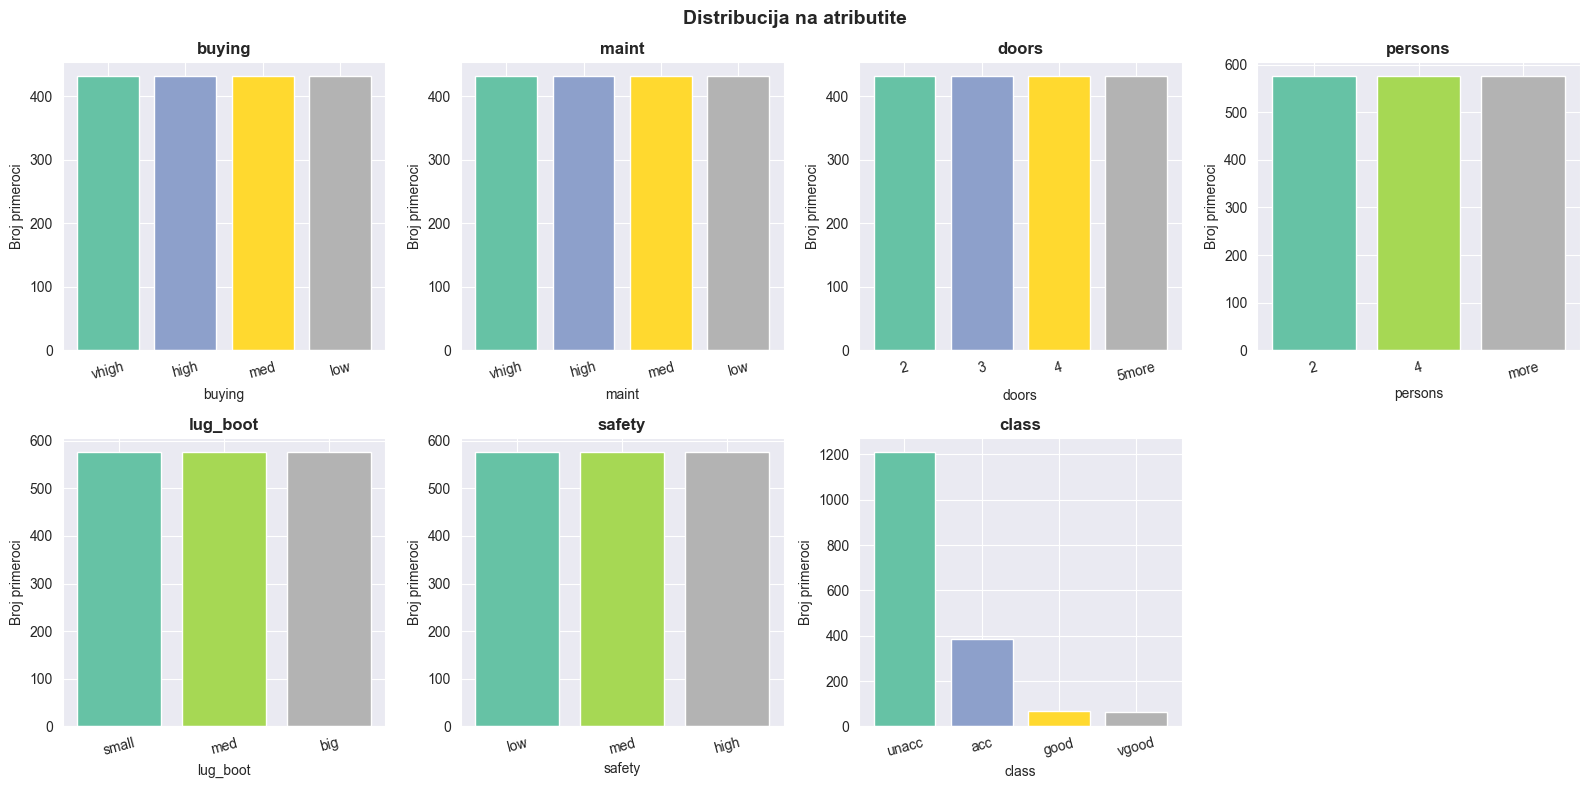

In [8]:
fig, axes = plt.subplots(2, 4, figsize = (16, 8))
axes = axes.flatten()

for i, col in enumerate(df.columns):
    counts = df[col].value_counts()
    axes[i].bar(counts.index, counts.values, color = plt.cm.Set2(np.linspace(0, 1, len(counts))))
    axes[i].set_title(f'{col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Broj primeroci')
    axes[i].tick_params(axis='x', rotation=15)
axes[-1].set_visible(False)
plt.suptitle('Distribucija na atributite', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [9]:
df_encoded = df.copy()
encoders = {}
for col in df.columns:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df[col])
    encoders[col] = le
    print(f"{col}: {dict(zip(le.classes_, le.transform(le.classes_)))}")
print("Podatocite posle enkodiranje:")
df_encoded.head()

buying: {'high': np.int64(0), 'low': np.int64(1), 'med': np.int64(2), 'vhigh': np.int64(3)}
maint: {'high': np.int64(0), 'low': np.int64(1), 'med': np.int64(2), 'vhigh': np.int64(3)}
doors: {'2': np.int64(0), '3': np.int64(1), '4': np.int64(2), '5more': np.int64(3)}
persons: {'2': np.int64(0), '4': np.int64(1), 'more': np.int64(2)}
lug_boot: {'big': np.int64(0), 'med': np.int64(1), 'small': np.int64(2)}
safety: {'high': np.int64(0), 'low': np.int64(1), 'med': np.int64(2)}
class: {'acc': np.int64(0), 'good': np.int64(1), 'unacc': np.int64(2), 'vgood': np.int64(3)}
Podatocite posle enkodiranje:


,buying,maint,doors,persons,lug_boot,safety,class
0,3,3,0,0,2,1,2
1,3,3,0,0,2,2,2
2,3,3,0,0,2,0,2
3,3,3,0,0,1,1,2
4,3,3,0,0,1,2,2


In [12]:
X = df_encoded.drop('class', axis=1)
y = df_encoded['class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Trening mnozestvo: {X_train.shape}")
print(f"Test mnozestvo: {X_test.shape}")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

Trening mnozestvo: (1382, 6)
Test mnozestvo: (346, 6)


In [13]:
#Decision Tree

dt_configs = [
    {'max_depth': None, 'min_samples_split': 2, 'criterion': 'gini', 'label': 'Default'},
    {'max_depth': 3, 'min_samples_split': 2, 'criterion': 'gini', 'label': 'max_depth=3, gini'},
    {'max_depth': 5, 'min_samples_split': 2, 'criterion': 'gini', 'label': 'max_depth=5, gini'},
    {'max_depth': 5, 'min_samples_split': 10, 'criterion': 'gini', 'label': 'max_depth=5, gini, min_split=10'},
    {'max_depth': 5, 'min_samples_split': 2, 'criterion': 'entropy', 'label': 'max_depth=5, entropy, min_split=2'},
    {'max_depth': 10, 'min_samples_split': 5, 'criterion': 'entropy', 'label': 'max_depth=10, entropy, min_split=5'},
]
dt_results = []
for cfg in dt_configs:
    label = cfg.pop('label')
    dt = DecisionTreeClassifier(**cfg, random_state=42)
    dt.fit(X_train, y_train)
    y_pred = dt.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    print(f"{label:<42} | Acc: {acc:.4f} | F1: {f1:.4f}")
    dt_results.append({'label': label, 'acc': acc, 'f1': f1, **cfg})
    cfg['label'] = label

Default                                    | Acc: 0.9855 | F1: 0.9855
max_depth=3, gini                          | Acc: 0.7775 | F1: 0.7641
max_depth=5, gini                          | Acc: 0.8728 | F1: 0.8566
max_depth=5, gini, min_split=10            | Acc: 0.8728 | F1: 0.8566
max_depth=5, entropy, min_split=2          | Acc: 0.8526 | F1: 0.8366
max_depth=10, entropy, min_split=5         | Acc: 0.9769 | F1: 0.9774


              precision    recall  f1-score   support

         acc       0.95      0.99      0.97        77
        good       0.93      1.00      0.97        14
       unacc       1.00      0.99      1.00       242
       vgood       1.00      0.85      0.92        13

    accuracy                           0.99       346
   macro avg       0.97      0.96      0.96       346
weighted avg       0.99      0.99      0.99       346



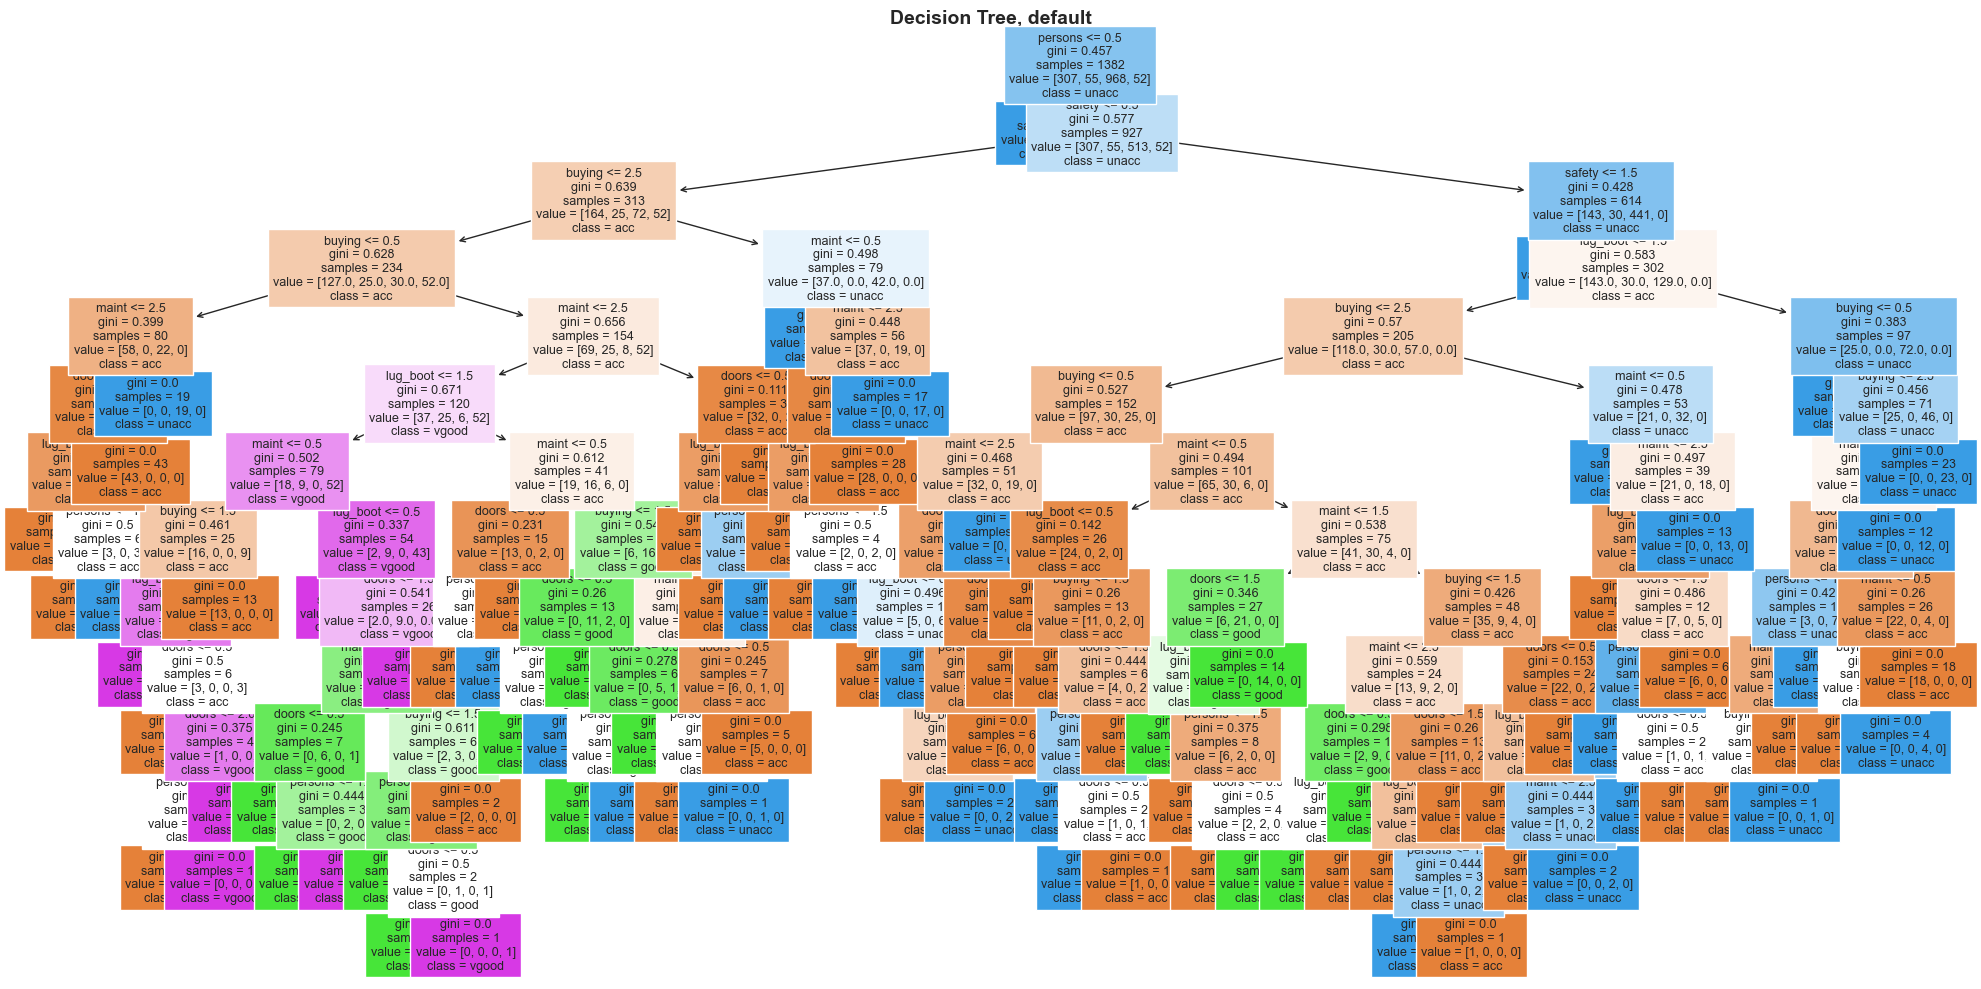

In [16]:
best_dt = DecisionTreeClassifier(max_depth=None, min_samples_split=2, criterion='gini', random_state=42)
best_dt.fit(X_train, y_train)
y_pred_dt = best_dt.predict(X_test)
print(classification_report(y_test, y_pred_dt, target_names=encoders['class'].classes_))
fig, ax = plt.subplots(figsize=(20,10))
plot_tree(
    best_dt,
    feature_names=X.columns.tolist(),
    class_names=encoders['class'].classes_,
    filled=True,
    fontsize=9,
    ax=ax
)
ax.set_title("Decision Tree, default", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

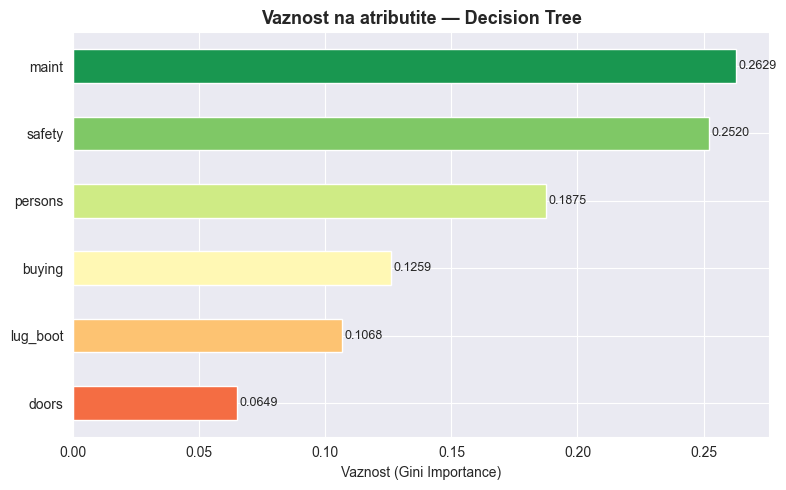


Vaznost po atribut:
maint       0.262886
safety      0.252009
persons     0.187535
buying      0.125893
lug_boot    0.106768
doors       0.064909
dtype: float64


In [17]:
importances_dt = pd.Series(best_dt.feature_importances_, index=X.columns)
importances_dt = importances_dt.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(importances_dt)))
importances_dt.plot(kind='barh', ax=ax, color=colors)
ax.set_title('Vaznost na atributite — Decision Tree', fontsize=13, fontweight='bold')
ax.set_xlabel('Vaznost (Gini Importance)')
for i, v in enumerate(importances_dt):
    ax.text(v + 0.001, i, f'{v:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

print("\nVaznost po atribut:")
print(importances_dt.sort_values(ascending=False))

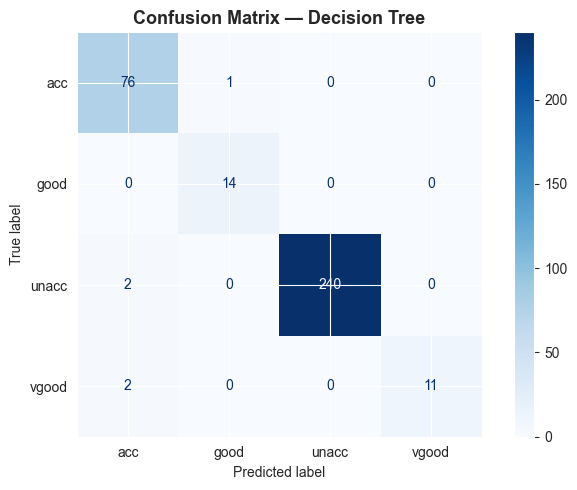

In [18]:
fig, ax = plt.subplots(figsize=(7, 5))
cm = confusion_matrix(y_test, y_pred_dt)
disp = ConfusionMatrixDisplay(cm, display_labels=encoders['class'].classes_)
disp.plot(ax=ax, colorbar=True, cmap='Blues')
ax.set_title('Confusion Matrix — Decision Tree', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [20]:
# Random Forest

rf_configs = [
    {'n_estimators': 10,  'max_features': 'sqrt', 'bootstrap': True,  'label': 'n=10,  sqrt, bootstrap=True'},
    {'n_estimators': 50,  'max_features': 'sqrt', 'bootstrap': True,  'label': 'n=50,  sqrt, bootstrap=True'},
    {'n_estimators': 100, 'max_features': 'sqrt', 'bootstrap': True,  'label': 'n=100, sqrt, bootstrap=True'},
    {'n_estimators': 100, 'max_features': 'log2', 'bootstrap': True,  'label': 'n=100, log2, bootstrap=True'},
    {'n_estimators': 100, 'max_features': None,   'bootstrap': True,  'label': 'n=100, all features, bootstrap=True'},
    {'n_estimators': 100, 'max_features': 'sqrt', 'bootstrap': False, 'label': 'n=100, sqrt, bootstrap=False'},
    {'n_estimators': 200, 'max_features': 'sqrt', 'bootstrap': True,  'label': 'n=200, sqrt, bootstrap=True'},
]

rf_results = []
for cfg in rf_configs:
    label = cfg.pop('label')
    rf = RandomForestClassifier(**cfg, random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred, average='weighted')
    print(f"{label:<42} | Acc: {acc:.4f} | F1: {f1:.4f}")
    rf_results.append({'label': label, 'acc': acc, 'f1': f1})
    cfg['label'] = label

n=10,  sqrt, bootstrap=True                | Acc: 0.9509 | F1: 0.9511
n=50,  sqrt, bootstrap=True                | Acc: 0.9798 | F1: 0.9795
n=100, sqrt, bootstrap=True                | Acc: 0.9827 | F1: 0.9825
n=100, log2, bootstrap=True                | Acc: 0.9827 | F1: 0.9825
n=100, all features, bootstrap=True        | Acc: 0.9913 | F1: 0.9913
n=100, sqrt, bootstrap=False               | Acc: 0.9855 | F1: 0.9855
n=200, sqrt, bootstrap=True                | Acc: 0.9798 | F1: 0.9796


              precision    recall  f1-score   support

         acc       0.99      0.97      0.98        77
        good       0.93      1.00      0.97        14
       unacc       1.00      1.00      1.00       242
       vgood       1.00      0.92      0.96        13

    accuracy                           0.99       346
   macro avg       0.98      0.97      0.98       346
weighted avg       0.99      0.99      0.99       346



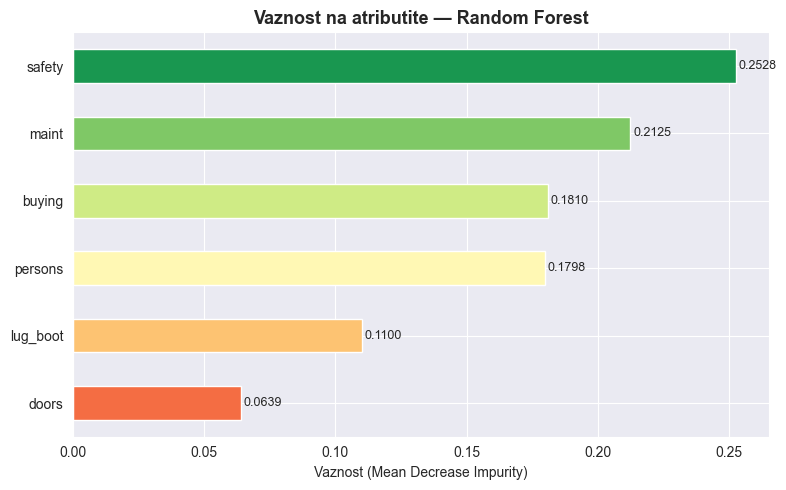

In [23]:
best_rf = RandomForestClassifier(n_estimators=100, max_features=None,
                                  bootstrap=True, random_state=42, n_jobs=-1)
best_rf.fit(X_train, y_train)
y_pred_rf = best_rf.predict(X_test)
print(classification_report(y_test, y_pred_rf,
      target_names=encoders['class'].classes_))

importances_rf = pd.Series(best_rf.feature_importances_, index=X.columns)
importances_rf = importances_rf.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(importances_rf)))
importances_rf.plot(kind='barh', ax=ax, color=colors)
ax.set_title('Vaznost na atributite — Random Forest', fontsize=13, fontweight='bold')
ax.set_xlabel('Vaznost (Mean Decrease Impurity)')
for i, v in enumerate(importances_rf):
    ax.text(v + 0.001, i, f'{v:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

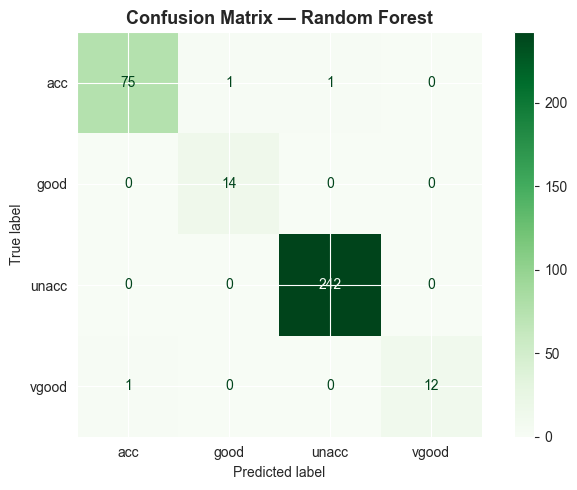

In [24]:
# Confusion Matrix — Random Forest
fig, ax = plt.subplots(figsize=(7, 5))
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(cm_rf, display_labels=encoders['class'].classes_)
disp.plot(ax=ax, colorbar=True, cmap='Greens')
ax.set_title('Confusion Matrix — Random Forest', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [25]:
# Neural Network - MLP

nn_configs = [
    {'hidden_layer_sizes': (50,),        'activation': 'relu',    'learning_rate_init': 0.001, 'label': '(50,)     relu   lr=0.001'},
    {'hidden_layer_sizes': (100,),       'activation': 'relu',    'learning_rate_init': 0.001, 'label': '(100,)    relu   lr=0.001'},
    {'hidden_layer_sizes': (100, 50),    'activation': 'relu',    'learning_rate_init': 0.001, 'label': '(100,50)  relu   lr=0.001'},
    {'hidden_layer_sizes': (100, 50),    'activation': 'tanh',    'learning_rate_init': 0.001, 'label': '(100,50)  tanh   lr=0.001'},
    {'hidden_layer_sizes': (100, 50),    'activation': 'logistic','learning_rate_init': 0.001, 'label': '(100,50)  logistic lr=0.001'},
    {'hidden_layer_sizes': (100, 50),    'activation': 'relu',    'learning_rate_init': 0.01,  'label': '(100,50)  relu   lr=0.01'},
    {'hidden_layer_sizes': (100, 50),    'activation': 'relu',    'learning_rate_init': 0.0001,'label': '(100,50)  relu   lr=0.0001'},
    {'hidden_layer_sizes': (200, 100, 50),'activation': 'relu',   'learning_rate_init': 0.001, 'label': '(200,100,50) relu lr=0.001'},
]

nn_results = []
for cfg in nn_configs:
    label = cfg.pop('label')
    nn = MLPClassifier(**cfg, max_iter=500, random_state=42)
    nn.fit(X_train_scaled, y_train)
    y_pred = nn.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred, average='weighted')
    print(f"{label:<40} | Acc: {acc:.4f} | F1: {f1:.4f}")
    nn_results.append({'label': label, 'acc': acc, 'f1': f1})
    cfg['label'] = label

C:\Users\nasto\PycharmProjects\MU_examples\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


(50,)     relu   lr=0.001                | Acc: 0.9653 | F1: 0.9650


C:\Users\nasto\PycharmProjects\MU_examples\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


(100,)    relu   lr=0.001                | Acc: 0.9740 | F1: 0.9741
(100,50)  relu   lr=0.001                | Acc: 0.9798 | F1: 0.9797
(100,50)  tanh   lr=0.001                | Acc: 0.9769 | F1: 0.9767


C:\Users\nasto\PycharmProjects\MU_examples\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


(100,50)  logistic lr=0.001              | Acc: 0.9162 | F1: 0.9083
(100,50)  relu   lr=0.01                 | Acc: 0.9769 | F1: 0.9767


C:\Users\nasto\PycharmProjects\MU_examples\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


(100,50)  relu   lr=0.0001               | Acc: 0.9393 | F1: 0.9387
(200,100,50) relu lr=0.001               | Acc: 0.9798 | F1: 0.9795


              precision    recall  f1-score   support

         acc       0.97      0.94      0.95        77
        good       1.00      1.00      1.00        14
       unacc       0.98      0.99      0.99       242
       vgood       0.93      1.00      0.96        13

    accuracy                           0.98       346
   macro avg       0.97      0.98      0.98       346
weighted avg       0.98      0.98      0.98       346



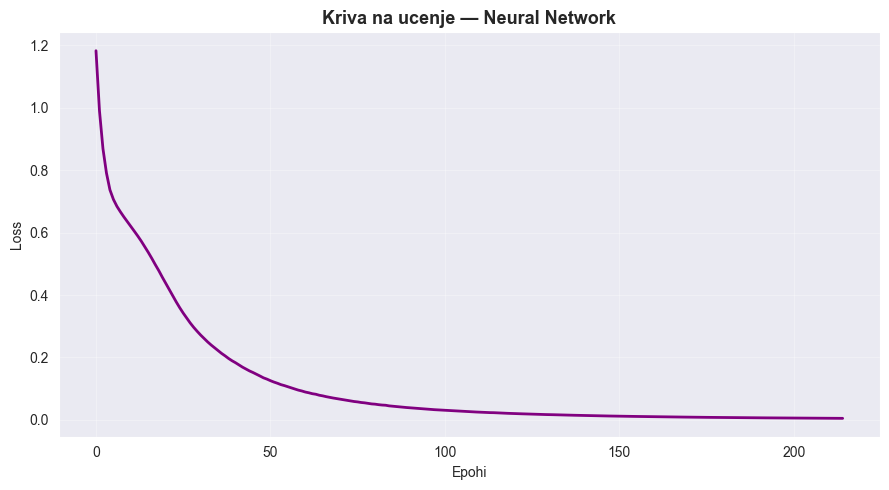

Konvergiral za 215 iteracii
Final loss: 0.004957


In [26]:
best_nn = MLPClassifier(
    hidden_layer_sizes=(100, 50),
    activation='relu',
    learning_rate_init=0.001,
    max_iter=500,
    random_state=42
)
best_nn.fit(X_train_scaled, y_train)
y_pred_nn = best_nn.predict(X_test_scaled)

print(classification_report(y_test, y_pred_nn,
      target_names=encoders['class'].classes_))

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(best_nn.loss_curve_, color='purple', linewidth=2)
ax.set_xlabel('Epohi')
ax.set_ylabel('Loss')
ax.set_title('Kriva na ucenje — Neural Network', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Konvergiral za {best_nn.n_iter_} iteracii")
print(f"Final loss: {best_nn.loss_:.6f}")

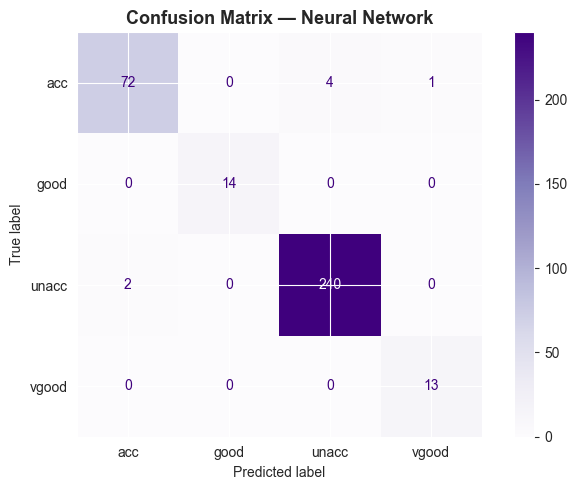

In [27]:
fig, ax = plt.subplots(figsize=(7, 5))
cm_nn = confusion_matrix(y_test, y_pred_nn)
disp = ConfusionMatrixDisplay(cm_nn, display_labels=encoders['class'].classes_)
disp.plot(ax=ax, colorbar=True, cmap='Purples')
ax.set_title('Confusion Matrix — Neural Network', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [29]:
models = {
    'Decision Tree': (y_pred_dt, 'steelblue'),
    'Random Forest': (y_pred_rf, 'seagreen'),
    'Neural Network': (y_pred_nn, 'mediumpurple'),
}

comparison = []
print(f"{'Model':<20} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1-Score':>10}")
print("-" * 62)

for name, (y_pred, color) in models.items():
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    print(f"{name:<20} {acc:>10.4f} {prec:>10.4f} {rec:>10.4f} {f1:>10.4f}")
    comparison.append({'Model': name, 'Accuracy': acc, 'Precision': prec,
                        'Recall': rec, 'F1-Score': f1, 'Color': color})

df_comp = pd.DataFrame(comparison)

Model                  Accuracy  Precision     Recall   F1-Score
--------------------------------------------------------------
Decision Tree            0.9855     0.9862     0.9855     0.9855
Random Forest            0.9913     0.9915     0.9913     0.9913
Neural Network           0.9798     0.9798     0.9798     0.9797


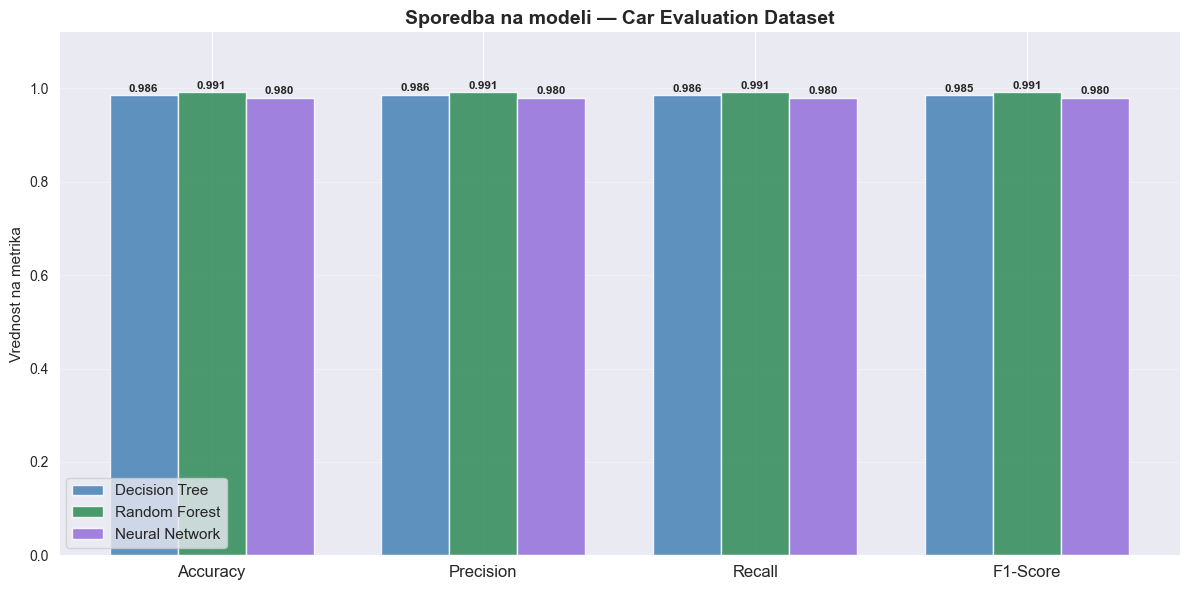

In [30]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(metrics))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))

for i, row in df_comp.iterrows():
    vals = [row[m] for m in metrics]
    bars = ax.bar(x + i*width, vals, width, label=row['Model'],
                  color=row['Color'], alpha=0.85, edgecolor='white')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8.5, fontweight='bold')

ax.set_xticks(x + width)
ax.set_xticklabels(metrics, fontsize=12)
ax.set_ylim(0, 1.12)
ax.set_ylabel('Vrednost na metrika', fontsize=11)
ax.set_title('Sporedba na modeli — Car Evaluation Dataset', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

In [34]:
print(df_comp[['Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score']].to_string(index=False))

best_model = df_comp.loc[df_comp['F1-Score'].idxmax(), 'Model']
best_f1    = df_comp['F1-Score'].max()
print(f"\n Najdobar model: {best_model} (F1 = {best_f1:.4f})")

         Model  Accuracy  Precision   Recall  F1-Score
 Decision Tree  0.985549   0.986175 0.985549  0.985484
 Random Forest  0.991329   0.991496 0.991329  0.991296
Neural Network  0.979769   0.979836 0.979769  0.979657

 Najdobar model: Random Forest (F1 = 0.9913)
